<a href="https://colab.research.google.com/github/zaibshahzadi/DL-Internship/blob/main/Deeplearning_Breast_Cancer_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries + Data Load**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])   # id useless, Unnamed:32 poori khali column
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Features (X) and Label (y)**

In [ ]:
X = df.drop(columns=["diagnosis"]).values.astype(float)   # 30 features

# Binary label: Malignant = 1, Benign = 0
y = np.where(df["diagnosis"].values == "M", 1, 0).reshape(-1, 1)

print(X.shape, y.shape)

(569, 30) (569, 1)


**Train/Test Split + Standardization**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train_T = X_train.T
X_test_T = X_test.T
y_train_T = y_train.T
y_test_T = y_test.T

**Parameters Initialize**

In [ ]:
np.random.seed(42)

n_x = X_train_T.shape[0]   # input features = 30 (Iris mein 4 thay)
n_h = 16                   # hidden neurons (zyada features hain isliye thora bara rakha)
n_y = 1                    # output neuron (binary)

W1 = np.random.randn(n_h, n_x) * 0.01
b1 = np.zeros((n_h, 1))
W2 = np.random.randn(n_y, n_h) * 0.01
b2 = np.zeros((n_y, 1))

**Activation Functions**

In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Forward Propagation**

In [ ]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

**Cost Function (Binary Cross-Entropy)**

In [ ]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    eps = 1e-8
    cost = -np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps)) / m
    return float(np.squeeze(cost))

**Backward Propagation**

In [ ]:
def backward_propagation(X, Y, cache, W2):
    m = X.shape[1]
    Z1, A1, Z2, A2 = cache

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2

**Update Parameters + Accuracy Function**

In [ ]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

def accuracy(A2, Y):
    predictions = (A2 > 0.5).astype(int)
    return float(np.mean(predictions == Y))

**Training Loop**

In [ ]:
learning_rate = 0.1     # Iris se kam rakha hai (0.5 se), warna is dataset pe training unstable ho sakti hai
epochs = 3000

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    A2_train, cache = forward_propagation(X_train_T, W1, b1, W2, b2)
    cost = compute_cost(A2_train, y_train_T)
    dW1, db1, dW2, db2 = backward_propagation(X_train_T, y_train_T, cache, W2)
    W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

    A2_test, _ = forward_propagation(X_test_T, W1, b1, W2, b2)
    test_cost = compute_cost(A2_test, y_test_T)

    train_losses.append(cost)
    test_losses.append(test_cost)
    train_accs.append(accuracy(A2_train, y_train_T))
    test_accs.append(accuracy(A2_test, y_test_T))

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Train Loss: {cost:.4f} | Test Loss: {test_cost:.4f} "
              f"| Train Acc: {train_accs[-1]:.3f} | Test Acc: {test_accs[-1]:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch    0 | Train Loss: 0.6935 | Test Loss: 0.6917 | Train Acc: 0.270 | Test Acc: 0.632
Epoch  500 | Train Loss: 0.0531 | Test Loss: 0.0587 | Train Acc: 0.985 | Test Acc: 0.991
Epoch 1000 | Train Loss: 0.0414 | Test Loss: 0.0634 | Train Acc: 0.987 | Test Acc: 0.991
Epoch 1500 | Train Loss: 0.0334 | Test Loss: 0.0787 | Train Acc: 0.991 | Test Acc: 0.982
Epoch 2000 | Train Loss: 0.0269 | Test Loss: 0.0986 | Train Acc: 0.991 | Test Acc: 0.982
Epoch 2500 | Train Loss: 0.0221 | Test Loss: 0.1191 | Train Acc: 0.991 | Test Acc: 0.982

Final Test Accuracy: 98.25%


**Loss & Accuracy Curves**

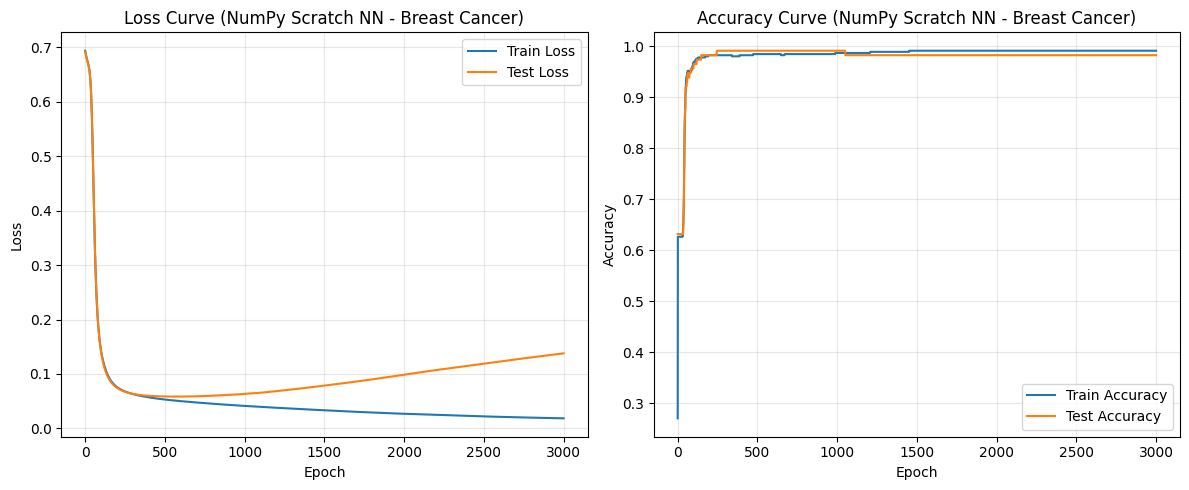

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (NumPy Scratch NN - Breast Cancer)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (NumPy Scratch NN - Breast Cancer)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluation Metrics**

Confusion Matrix:
[[72  0]
 [ 2 40]]

Precision: 1.0000
Recall:    0.9524
F1-Score:  0.9756

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



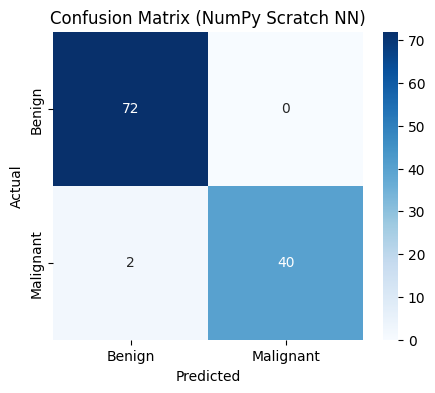

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

final_preds = (A2_test > 0.5).astype(int).flatten()
final_actual = y_test_T.flatten()

cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

precision = precision_score(final_actual, final_preds)
recall = recall_score(final_actual, final_preds)
f1 = f1_score(final_actual, final_preds)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=["Benign", "Malignant"]))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix (NumPy Scratch NN)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

**Re-implementation using PyTorch — Dropout + L2 Regularization**

**Imports Libraries**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

torch.manual_seed(42)
np.random.seed(42)

**Data Load + Preprocessing**

In [ ]:
df = pd.read_csv("data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])

X = df.drop(columns=["diagnosis"]).values.astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(df["diagnosis"].values)   # B=0, M=1
print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

Classes: ['B', 'M']


**MLP Model**

In [ ]:
class BCMLP(nn.Module):
    def __init__(self, in_features=30, hidden1=32, hidden2=16, out_classes=2, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden2, out_classes)
        )

    def forward(self, x):
        return self.net(x)

model = BCMLP()
print(model)

BCMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)


**Loss + Optimizer (L2 Regularization)**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

**Training Loop**

In [ ]:
epochs = 200
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    train_preds = outputs.argmax(dim=1)
    train_acc = (train_preds == y_train_t).float().mean().item()

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t)
        test_preds = test_outputs.argmax(dim=1)
        test_acc = (test_preds == y_test_t).float().mean().item()

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} "
              f"| Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch   0 | Train Loss: 0.6742 | Test Loss: 0.6597 | Train Acc: 0.613 | Test Acc: 0.816
Epoch  20 | Train Loss: 0.5211 | Test Loss: 0.4849 | Train Acc: 0.866 | Test Acc: 0.921
Epoch  40 | Train Loss: 0.3560 | Test Loss: 0.3121 | Train Acc: 0.910 | Test Acc: 0.930
Epoch  60 | Train Loss: 0.2183 | Test Loss: 0.1825 | Train Acc: 0.949 | Test Acc: 0.956
Epoch  80 | Train Loss: 0.1455 | Test Loss: 0.1116 | Train Acc: 0.960 | Test Acc: 0.974
Epoch 100 | Train Loss: 0.1054 | Test Loss: 0.0829 | Train Acc: 0.967 | Test Acc: 0.982
Epoch 120 | Train Loss: 0.0880 | Test Loss: 0.0719 | Train Acc: 0.980 | Test Acc: 0.982
Epoch 140 | Train Loss: 0.0806 | Test Loss: 0.0660 | Train Acc: 0.974 | Test Acc: 0.982
Epoch 160 | Train Loss: 0.0574 | Test Loss: 0.0655 | Train Acc: 0.989 | Test Acc: 0.982
Epoch 180 | Train Loss: 0.0537 | Test Loss: 0.0641 | Train Acc: 0.991 | Test Acc: 0.982

Final Test Accuracy: 98.25%


**Loss & Accuracy Curves python**

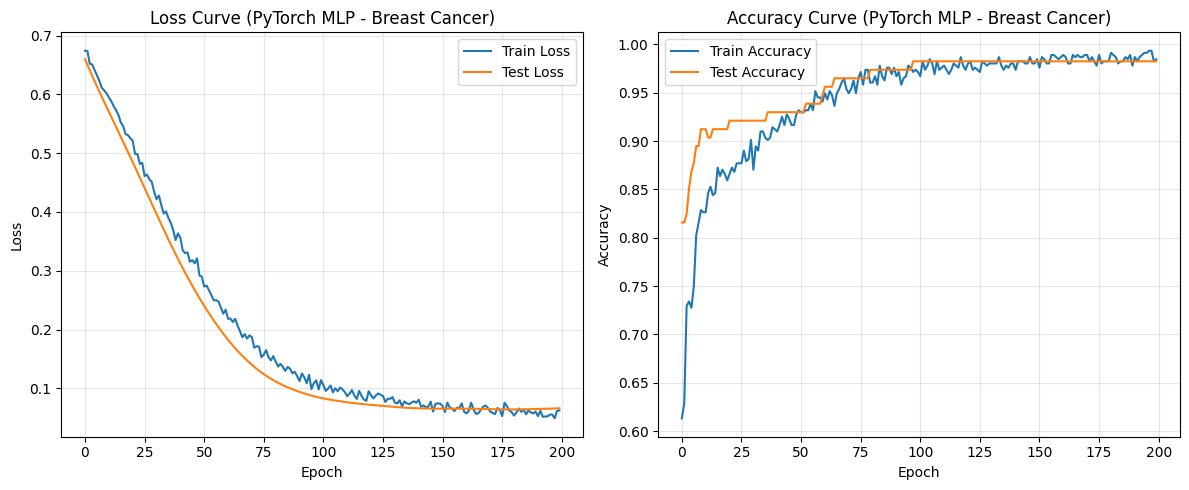

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (PyTorch MLP - Breast Cancer)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (PyTorch MLP - Breast Cancer)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluation Metrics**

Confusion Matrix:
[[72  0]
 [ 2 40]]

Precision (macro): 0.9865
Recall (macro):    0.9762
F1-Score (macro):  0.9810

Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



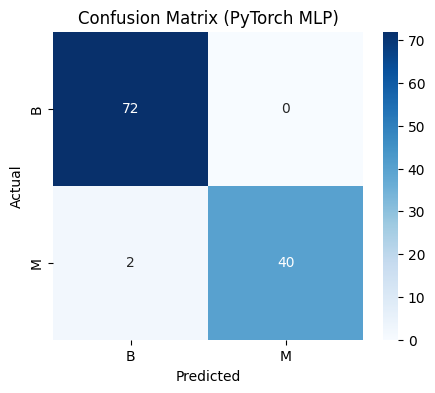

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    final_outputs = model(X_test_t)
    final_preds = final_outputs.argmax(dim=1).numpy()

final_actual = y_test_t.numpy()
class_names = list(le.classes_)   # ['B', 'M']

cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

precision = precision_score(final_actual, final_preds, average="macro")
recall = recall_score(final_actual, final_preds, average="macro")
f1 = f1_score(final_actual, final_preds, average="macro")
print(f"\nPrecision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-Score (macro):  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=class_names))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (PyTorch MLP)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()